In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import plotly.express as px


In [37]:
df = pd.read_csv("../data/European_Bank.csv")

In [38]:
df.head()


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
df.shape

(10000, 14)

In [40]:
df.columns


Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [41]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [42]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [43]:
df.describe()


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [44]:
df.drop(columns=["CustomerId", "Surname"], inplace=True)

In [45]:
df.head()


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [46]:
df.duplicated().sum()


np.int64(0)

In [47]:
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

In [48]:
bins = [18,30,45,60,100]

labels = ["Young","Adult","Mid-Age","Senior"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [49]:
def credit_segment(score):

    if score < 500:
        return "Low"

    elif score < 700:
        return "Medium"

    else:
        return "High"


df["CreditSegment"] = df["CreditScore"].apply(credit_segment)

In [50]:
def balance_segment(balance):

    if balance == 0:
        return "Zero Balance"

    elif balance < 100000:
        return "Low Balance"

    else:
        return "High Balance"


df["BalanceSegment"] = df["Balance"].apply(balance_segment)

In [51]:
def tenure_group(years):

    if years <= 3:
        return "New"

    elif years <= 7:
        return "Mid-Term"

    else:
        return "Long-Term"


df["TenureGroup"] = df["Tenure"].apply(tenure_group)

In [52]:
churn_rate = df["Exited"].mean() * 100

print(churn_rate)

20.369999999999997


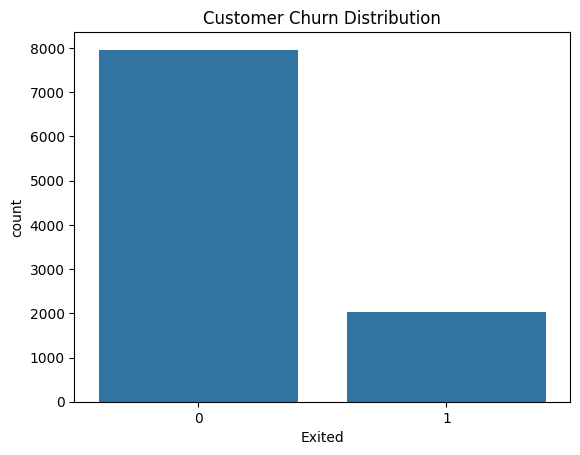

In [53]:
sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [54]:
geo_churn = df.groupby("Geography")["Exited"].mean() * 100

print(geo_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


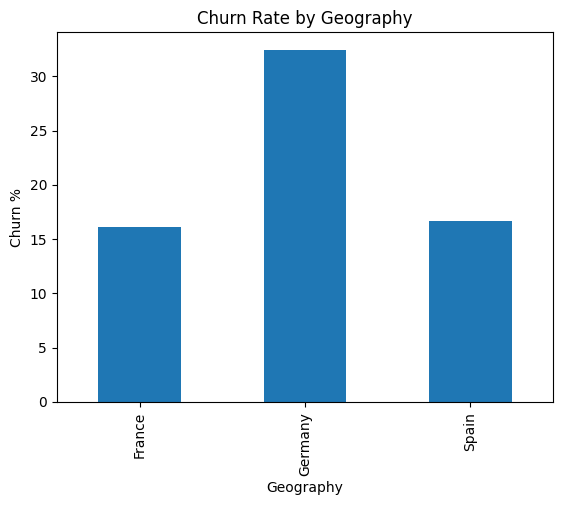

In [55]:
geo_churn.plot(kind="bar")

plt.title("Churn Rate by Geography")

plt.ylabel("Churn %")

plt.show()

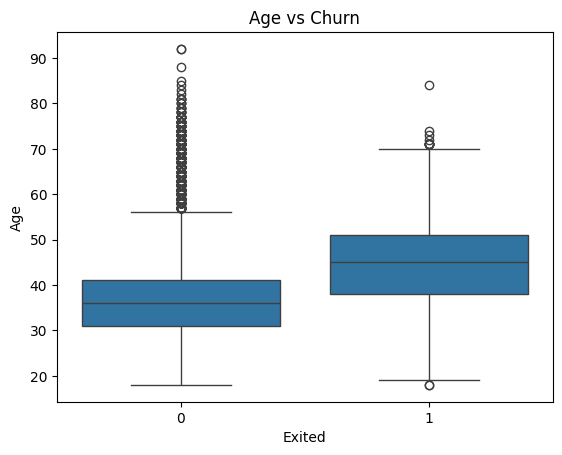

In [56]:
sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age vs Churn")

plt.show()

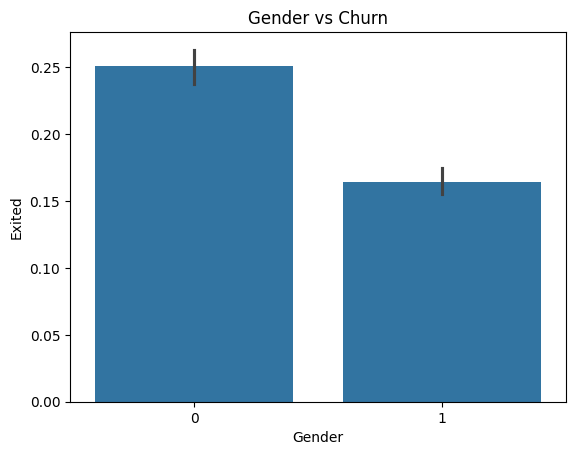

In [57]:
sns.barplot(x="Gender", y="Exited", data=df)

plt.title("Gender vs Churn")

plt.show()

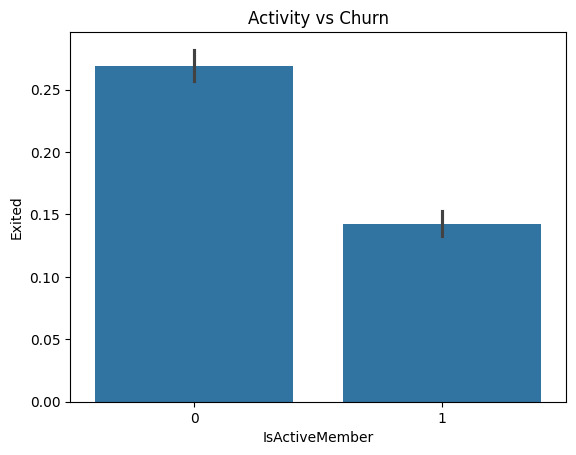

In [58]:
sns.barplot(
    x="IsActiveMember",
    y="Exited",
    data=df
)

plt.title("Activity vs Churn")

plt.show()

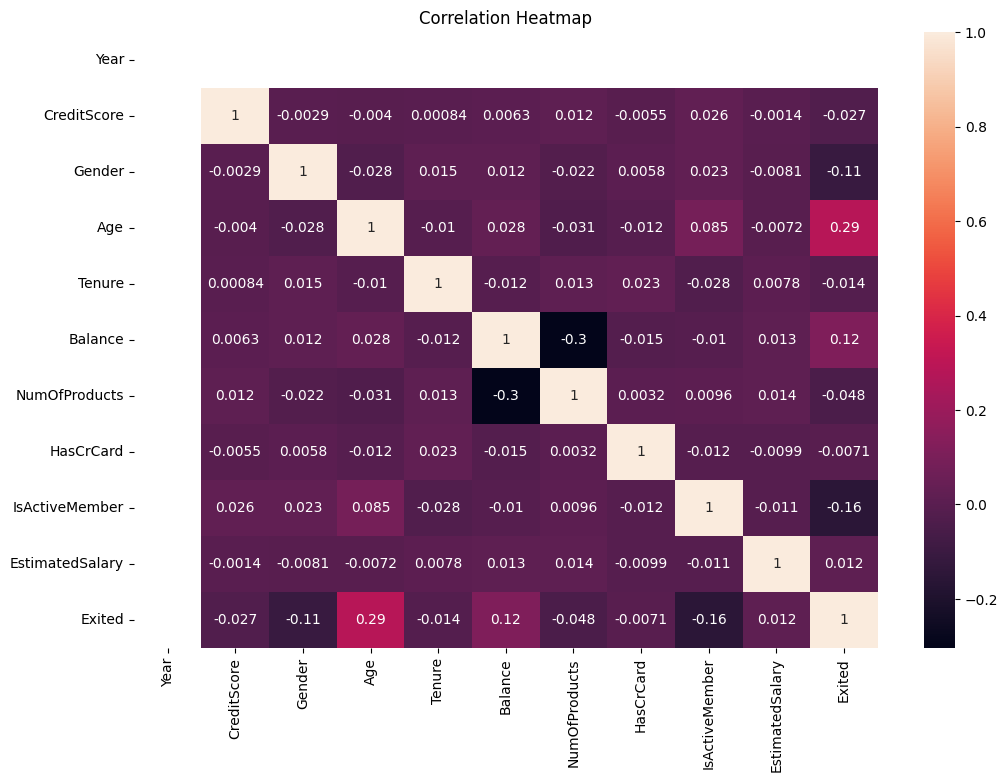

In [59]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [60]:
high_value = df[df["Balance"] > 100000]

high_value["Exited"].mean() * 100

np.float64(25.234423838299648)

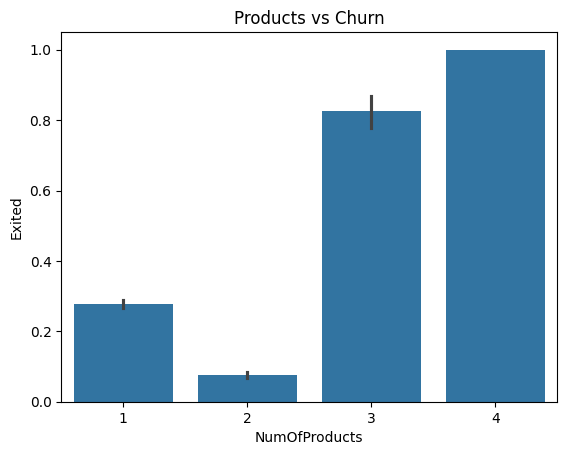

In [61]:
sns.barplot(
    x="NumOfProducts",
    y="Exited",
    data=df
)

plt.title("Products vs Churn")

plt.show()

In [62]:
df.to_csv("../data/cleaned_churn.csv", index=False)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [64]:
le = LabelEncoder()

df["Geography"] = le.fit_transform(df["Geography"])

In [65]:
X = df.drop([
    "Exited",
    "AgeGroup",
    "CreditSegment",
    "BalanceSegment",
    "TenureGroup"
], axis=1)

y = df["Exited"]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
predictions = model.predict(X_test)

In [69]:
accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.8655


In [70]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Age,0.240328
10,EstimatedSalary,0.148261
1,CreditScore,0.145718
6,Balance,0.137978
7,NumOfProducts,0.130244
5,Tenure,0.082209
9,IsActiveMember,0.042419
2,Geography,0.036209
8,HasCrCard,0.018568
3,Gender,0.018067


In [77]:
country = st.sidebar.selectbox(
    "Select Country",
    df["Geography"].unique()
)

filtered_df = df[
    df["Geography"] == country
]

2026-05-28 14:30:02.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:30:02.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [80]:
fig = px.histogram(
    filtered_df,
    x="Age",
    color="Exited"
)

st.plotly_chart(fig)

2026-05-28 14:47:43.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:47:43.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:47:43.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:47:43.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:47:43.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()